# Day 25 Pre-Class Assignment
---


### <p style="text-align: right;"> &#9989;&nbsp; Put your name here</p>

## Confidence and prediction intervals; confidence and prediction bands

<img src="https://raw.githubusercontent.com/ejamezquita/plnt_sci2500/refs/heads/main/images/confidence_interval.png" style="display:block; margin-left: auto; margin-right: auto; width: 22.5%" alt="Comic depicting that arbitrarily large confidence intervals can exceed the plot limits and thus go unnoticed.">
<p style="font-size:0.85em; text-align: center;">Credits: <a href="https://xkcd.com/2311/" target="_blank">xkcd.com</a></p>

### Learning goals for today's pre-class assignment

* Recall how to use SciPy to compute linear regressions.
* Fit and interpret confidence bands and intervals to your linear prediction.
* Understand how confidence bands are similiar and different compared to confidence intervals

## Assignment instructions

**This assignment is due by 11:59 p.m. the day before class,** and should be uploaded into the appropriate "Pre-class assignments" submission folder.  If you run into issues with your code, make sure to use Slack to help each other out and receive some assistance from the instructors. Submission instructions can be found at the end of the notebook.

## Make all the needed imports before anything else

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from matplotlib import pyplot as plt
from sklearn import metrics

---

## 1. Revisiting linear models to predict oil and protein content in soybean genotypes

Back in Day 16 we used data from [DeMeyer et al (2024)](https://doi.org/10.1002/csc2.21356) and `stats.linregress` to compute the best fit line for oil versus protein content for various soybean cultivars (genotypes). We were able to reproduce the scatter points from Figure 2, the black best-fit lines, alongside all the relevant parameters, coefficients, and p-values.

Now we are going to finish the Figure 2 by also computing the *95% confidence band* in gray.

<img src="https://raw.githubusercontent.com/ejamezquita/plnt_sci2500/refs/heads/main/images/demeyer_etal_2024_f2.jpg" style="display:block; margin-left: auto; margin-right: auto; width: 50%" alt="Scatterplot of mean protein content (g kg<sup>-1</sup>) versus mean oil content (g kg<sup>-1</sup>) for 17 cultivars grown in two replications across nine environments in Zimbabwe during the summer 2019&ndash;2020 season. The regression equation, R2 value, and Pearson's correlation coefficient (r) are listed in the top left corner, and the 95% confidence interval is indicated in gray shading around the trendline.">
<p style="font-size:0.85em; text-align: center;">Credits: <a href="https://doi.org/10.1002/csc2.21356" target="_blank">DeMeyer et al (2024)</a></p>

### 1.1 Loading and grouping the data

- We first load the data set `PATSA_final_QCd_rep_data.csv` and make sure it looks good.

In [2]:
data = pd.read_csv('PATSA_final_QCd_rep_data.csv')
print('The dataset contains', data.shape[0], 'rows and', data.shape[1], 'columns.')
data.head()

The dataset contains 306 rows and 14 columns.


,GEN,REP,BLOCK,ENV,site,Elevation_M,Soil_pH,Soil_Na,Avg_temp,Cum_precip,PROTEIN_g/kg,OIL_g/kg,Country_of_Origin,Soil_Type
0,BIMHA,1,5,ENV1,CBI-Site 4,421,8.3,156,23.3,64.1,319.3,236.8,Zimbabwe,Chromic Luvisols
1,BIMHA,2,9,ENV1,CBI-Site 4,421,8.3,156,23.3,64.1,370.9,219.3,Zimbabwe,Chromic Luvisols
2,KALEYA,1,4,ENV1,CBI-Site 4,421,8.3,156,23.3,64.1,396.3,213.9,Zambia,Chromic Luvisols
3,KALEYA,2,6,ENV1,CBI-Site 4,421,8.3,156,23.3,64.1,378.6,219.3,Zambia,Chromic Luvisols
4,LUKANGA,1,3,ENV1,CBI-Site 4,421,8.3,156,23.3,64.1,364.8,219.5,Zambia,Chromic Luvisols


- If you recall from Day 16, we then average all the replicates for every cultivar/environment combination
- Now we can use `groupby` to group the rows if they share the same genotype and environment, and then get their mean protein and oil contents.

In [3]:
# Average protein and oil contents for every cultivar/environment combination
means = data.groupby(['GEN', 'ENV'], as_index=False)[['PROTEIN_g/kg', 'OIL_g/kg']].agg('mean')
means.head()

,GEN,ENV,PROTEIN_g/kg,OIL_g/kg
0,BIMHA,ENV1,345.10,228.05
1,BIMHA,ENV2,393.25,205.00
2,BIMHA,ENV3,403.50,205.05
3,BIMHA,ENV4,413.00,194.55
4,BIMHA,ENV5,419.15,188.10


- Get the best-fit line with `stats.linregress`
- Use it to predict the oil content of the protein values we have
- Compute the $R^2$ coefficient of determination by comparing these predicted oil values agains the actual oil values.
- Plot the mean oil versus protein content and the best-fit line

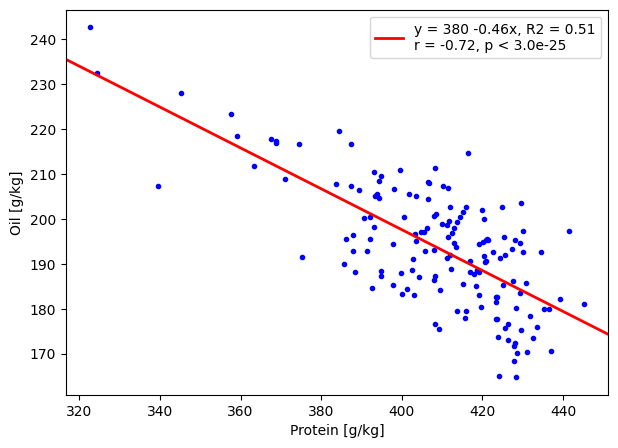

In [4]:
true_protein = means['PROTEIN_g/kg']
true_oil = means['OIL_g/kg']

linregress = stats.linregress(true_protein, true_oil)

pred_oil = linregress.slope*true_protein + linregress.intercept

r2 = metrics.r2_score(true_oil, pred_oil)

# Plotting everything

fig, ax = plt.subplots(1,1,figsize=(7,5))
ax = np.atleast_1d(ax).ravel()

ax[0].scatter(true_protein, true_oil, c='b', marker='.', zorder=1)

line_deets = 'y = {:.0f} {:.2f}x, R2 = {:.2f}\nr = {:.2f}, p < {:.1e}'.format(linregress.intercept, linregress.slope, r2, linregress.rvalue, linregress.pvalue)
ax[0].axline((true_protein.iloc[0], pred_oil.iloc[0]), slope=linregress.slope, c='r', lw=2, label=line_deets, zorder=2)
ax[0].legend(loc='upper right')
ax[0].set_xlabel('Protein [g/kg]')
ax[0].set_ylabel('Oil [g/kg]');

### 1.2 Model predictions

Linear regressions provide us with linear models:

$$y = b + mx.$$

In the soybean case, we have a linear model for oil and protein content values:

$$\text{Oil content} = 380 - 0.46\times\text{Protein content}.$$

For example, none of our datapoints has *exactly* 350g/kg of protein. The closest is 345 (Bimha, Env 1). Nonetheless, with our model, we can suggest that such grain would *likely* have about 220g/kg of oil as well.

In [5]:
protein = 350
oil = linregress.slope*protein + linregress.intercept
print('A cultivar with', protein, 'g/kg of protein will have', round(oil,1), 'g/kg of oil')

A cultivar with 350 g/kg of protein will have 220.4 g/kg of oil


- But how *likely* is likely?

---

## 2. Confidence bands for linear models

The model we stated above is **data-based**. If we were to repeat the experiment, we will likely collect different data, and **we might get a different model**. Hopefully not *too* different&mdash;like $\text{Oil} = 375-0.5\times\text{Protein}$&mdash;but different nonetheless. And this in turn will produce different prediction values.

Instead of saying that a soybean with 350g/kg protein will have&mdash;on average&mdash;220g/kg of oil, we want to provide a **confidence interval**: we want an interval of oil values such that if we repeat the experiment multiple times, our predicted oil content value will lie in it 95% of the time.

We have our trusty Confidence Interval formula:

$$\text{Confidence interval of the mean} = \text{Mean} \pm t_{\alpha, n-1}\times\text{Standard Error of the Mean}$$
Or more mathy:
$$\text{CI}_\alpha = \mu \pm t_{\alpha, n-1}\times\text{SE}.$$
But we **cannot** use the Confidence Interval formula as is now because we don't have any soybeans with 350g/kg of protein to begin with! We cannot compute the sample mean if we don't have a sample!

### 2.1 The math on confidence bands

We can compute the confidence interval for a linear model prediction $\hat y$ by following a very similar formula:

$$CI = \hat{y}\pm t_{\alpha,n-2}\times s_{\hat{y}}.$$

Here, $\hat{y}$ is our linear *prediction* and $s_{\hat{y}}$ is the standard error *of the prediction*, with the $t$ quantile having $n-2$ degrees of freedom (as opposed to $n-1$ as in the mean case.)

The standard error of the prediction is given by the formula:

$$s_{\hat{y}} = \sqrt{\text{MSE}\times\left(\frac1n + \frac{(x-\bar{x})^2}{SS_x}\right)},$$

where MSE is the *mean square error*:

$$\text{MSE} = \frac1{n-2}{\sum_{i=1}^n{{(y_i-\hat{y_i})^2}}},$$

and $SS_x$ is the sum of squared deviations for $x$-axis values:

$$SS_x = \sum_{i=1}^n(x_i - \bar{x})^2.$$

**That is a lot of math!!**

Don't worry: we will unpack it in the next section. The important pieces to keep in mind are:

- The $\hat y_i$'s are just the *predicted* oil content values `pred_oil`.
- The $y_i$'s are the *actual* observed oil content values `true_oil`.
- The $x_i$'s are the *actual* observed protein content values.
- The $\bar{x}$ is the sample mean of protein values.
- The plain $x$ is the protein value for which we want a confidence interval&mdash;like 350g/kg.

### 2.2 [OPTIONAL] Math intuition

The math behind these formulas goes beyond the scope of the course, but in high-level terms notice that

- The MSE keeps track of how good our model is. The MSE will be small if our linear model matches the actual measurements, and it will be large if our model is poor.
- SS<sub>x</sub> keeps track of how spread out are our observed x-axis values.
- $x - \bar{x}$ tells us how far the value we want to predict for is from the sample mean.

Putting it all together, the confidence band formula will produce large confidence bands if our linear model is bad at predicting actual values; these bands will be tighter if our linear model does a good job at predicting. Additionally, the band will be large if we want to predict for a value that is very distant from our observed x-axis values. The band is the smallest whenever we want to predict for values near the average x-axis value.

---

## 3. Going back to soybeans: a confidence band example with NumPy

Let's step away from math-land and go back to soybean-land. Keep in mind that NumPy is meant for these sort of tasks: no need for us to make loops.

### 3.1 The confidence interval for the oil prediction at 350g/kg of protein

Let's go back to our initial question: what is the confidence interval, according to our model, of oil content whenever we have **an average** soybean cultivar with 350g/kg of protein content?

- Going step-by-step. First get the MSE:

In [6]:
# Compute MSE in a single line (a bit hard to read at first but you'll get used to it)
mse = np.sum( (true_oil - pred_oil)**2 ) / ( len(true_oil) - 2)
print("The MSE value:\t", mse)

The MSE value:	 91.60947088028561


- Then get $SS_x$:

In [7]:
# SSx in a single line
ssx = np.sum( (true_protein - true_protein.mean())**2 )
print("The SSx value:\t", ssx)

The SSx value:	 69874.80640522874


- Get the standard error of the prediction $\hat{s}_y$ when considering 350 g/kg protein content:

In [8]:
# The standard error of the prediction for 350 of protein

protein = 350

sy = np.sqrt( mse*(1/len(true_protein) + (protein - true_protein.mean())**2/ssx) )
print("The standard prediction error for",protein,'g/kg protein value:\t', sy)

The standard prediction error for 350 g/kg protein value:	 2.2444834459998577


- Finally, put everything together to get the 95% confidence interval:

In [9]:
# Notice that we have n-2 degrees of freedom for t instead of n-1
t = stats.t.ppf( 0.975, len(true_protein) - 2)
oil = linregress.slope*protein + linregress.intercept #same as part 1.2

ci = t*sy

print('According to our model:')
print('\nThe AVERAGE soybean cultivar with',protein,'g/kg of protein will have between')
print(f'{oil-ci:.1f} -- {oil+ci:.1f} g/kg of oil 95% of the times.')

According to our model:

The AVERAGE soybean cultivar with 350 g/kg of protein will have between
215.9 -- 224.8 g/kg of oil 95% of the times.


---

## 4. But I was promised bands

The confidence interval above was compute for a *single* protein value. But just like with the switchgrass example from Day 21, we can compute confidence intervals for a *sequence* of protein values and then connect all those intervals into a band.

We'll first make an array of protein values, going from 320 to 450g/kg (the min and max in our dataset). And then we can simply plug it in in our previous code. Remember that NumPy and pandas are cool because we don't need loops to do this.

In [10]:
# array of 100 protein values between min and max
protein_band = np.linspace(true_protein.min(), true_protein.max(), 100)

# MSE and SSx do not need to be recomputed
# sy is almost the same as above
sy = np.sqrt( mse*(1/len(true_protein) + (protein_band - true_protein.mean())**2/ssx) )

ci = t*sy

# predict oil values for the `protein_band` values
oil_band = linregress.slope*protein_band + linregress.intercept

- We can [use the `.fill_between` function to](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.fill_between.html) plot a semi-transparent band.

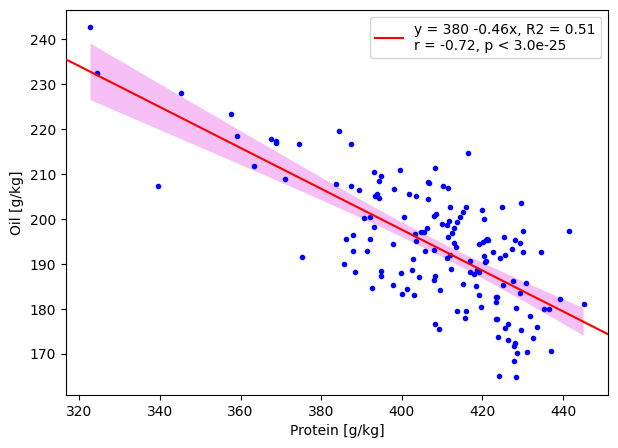

In [11]:
# make a plot

fig, ax = plt.subplots(1,1,figsize=(7,5))
ax = np.atleast_1d(ax).ravel()

ax[0].scatter(true_protein, true_oil, c='b', marker='.', zorder=2)
ax[0].axline((true_protein.iloc[0], pred_oil.iloc[0]), slope=linregress.slope, c='r', label=line_deets, zorder=3)
ax[0].fill_between(protein_band, oil_band-ci, oil_band+ci, alpha=0.5, color='violet', ec=None, zorder=1)
ax[0].legend(loc='upper right')
ax[0].set_xlabel('Protein [g/kg]')
ax[0].set_ylabel('Oil [g/kg]');

- If we were to repeat this soybean experiment multiple times, our best-fit line will end up within the magenta band 95% of the times!

Make sure this plot looks like the one in Figure 2 from [DeMeyer et al (2024)](https://doi.org/10.1002/csc2.21356).

The shape of this band immediately suggests that our *average* estimates of oil content will be the most accurate when examining cultivars with 410-ish g/kg of protein. As the protein content decreases, our estimates for oil content are more varied.

---

## 5. Prediction intervals and prediction bands

From the results above, we know that **for an average** soybean cultivar with 350 g/kg of protein will likely have somewhere between 216 and 225 g/kg of oil. The key phrase is *for an average cultivar*.

The above result **does not mean** that 95% of soybean cultivars with 350 g/kg of protein will have oil content limited to 216&ndash;225 g/kg. The 216&ndash;225 range only applies to average cultivars.

The magenta-shaded region above simply indicates that the best-fit line will be contained there 95% of the times. It **does not mean** that 95% of oil content values will lie there. Sure enough, more than half of our observed values (blue dots) are *outside* the magenta shade.

### 5.1 Prediction intervals

Soybean cultivars&mdash;and biology data in general&mdash;are anything but average. If we want to know the range of possible oil content values for *most* of the soybean cultivars with 350 g/kg protein contents, then we need to use *prediction intervals* instead.

We can compute the *prediction* interval for a linear model prediction $\hat y$ with:

$$CI = \hat{y}\pm t_{\alpha,n-2}\times \text{pred}_{\hat{y}},$$

where

$$\text{pred}_{\hat{y}} = \sqrt{\text{MSE}\times\left(1 + \frac1n + \frac{(x-\bar{x})^2}{SS_x}\right)}.$$

If you notice, the confidence and prediction intervals are *almost* the same. The only difference is that $\text{pred}_{\hat{y}}$ has an extra $1+$ compared to $s_{\hat y}$.

Let's look again at the soybeans with 350 g/kg of protein:

In [12]:
# Copy/pasting the code from (3.1), but for prediction intervals
protein = 350
oil = linregress.slope*protein + linregress.intercept #same as part 1.2

predy = np.sqrt( mse*(1 + 1/len(true_protein) + (protein - true_protein.mean())**2/ssx) )
ci = t*predy

print('According to our model:')
print('\nThe soybean cultivars with',protein,'g/kg of protein will have between')
print(f'{oil-ci:.1f} -- {oil+ci:.1f} g/kg of oil 95% of the times.')

According to our model:

The soybean cultivars with 350 g/kg of protein will have between
200.9 -- 239.8 g/kg of oil 95% of the times.


Now we can say that if we have a soybean cultivar with 350 g/kg of protein, its oil content will be somewhere between 201 and 240 g/kg for 95% of the times.

### 5.2 Prediction bands

Finally, we can repeat the same trick as with confidence bands: compute a bunch of prediction intervals and shade them all together. We can simply copy paste the code from Part 4 and make minimal edits:

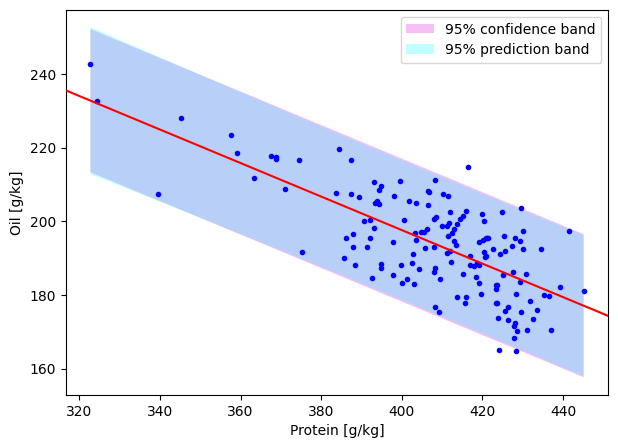

In [13]:
# prediction band
predy = np.sqrt( mse*(1 + 1/len(true_protein) + (protein_band - true_protein.mean())**2/ssx) )
pi = t*predy

# make a plot

fig, ax = plt.subplots(1,1,figsize=(7,5))
ax = np.atleast_1d(ax).ravel()

ax[0].scatter(true_protein, true_oil, c='b', marker='.', zorder=2)
ax[0].axline((true_protein.iloc[0], pred_oil.iloc[0]), slope=linregress.slope, c='r', zorder=3)
ax[0].fill_between(protein_band, oil_band-ci, oil_band+ci, alpha=0.5, color='violet', ec=None, zorder=1, label='95% confidence band')
ax[0].fill_between(protein_band, oil_band-pi, oil_band+pi, alpha=0.25, color='cyan', ec=None, zorder=1, label='95% prediction band')
ax[0].legend(loc='upper right')
ax[0].set_xlabel('Protein [g/kg]')
ax[0].set_ylabel('Oil [g/kg]');

Obviously, average cultivars are part of all the cultivars, so the prediction band contains the confidence band. And as the name suggests, our prediction band contains 95% of all our oil predictions (95% of our datapoints).

&#9989;&nbsp; **Question**

Keep in mind that it is not a matter of figuring out which interval/band is better: confidence vs. predition. It is rather a matter of know what each of the two mean.

In your own words, in soybean terms:

- Describe what is the usefulness of a confidence *band*. A single example is fine.
- Describe the usefulness of a prediction *interval*. A single example is fine.

<font size=6 color="#009600">&#9998;</font> *Your answer here*

---

## Congratulations, you're done!

Submit this assignment by uploading it to the course Canvas web page.  Go to the "Pre-class assignments" folder, find the appropriate submission folder link, and upload it there.

See you in class!

&#169; Copyright 2026,  Division of Plant Science & Technology&mdash;University of Missouri